In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
# Define the Patient class
class Patient:
    def __init__(self, patient_id, gender, age, height_m, weight_kg, bmi, systolic_bp, diastolic_bp,
                 blood_glucose_mmol, heart_rate, smoking_status, activity_level):
        self.patient_id = patient_id
        self.gender = gender
        self.age = age
        self.height_m = height_m
        self.weight_kg = weight_kg
        self.bmi = bmi
        self.systolic_bp = systolic_bp
        self.diastolic_bp = diastolic_bp
        self.blood_glucose_mmol = blood_glucose_mmol
        self.heart_rate = heart_rate
        self.smoking_status = smoking_status
        self.activity_level = activity_level
        self.blood_pressure_category = None
        self.risk_category = None

In [3]:
# Define the HealthAssessment class
class HealthAssessment:
    @staticmethod
    def calculate_bmi(weight_kg, height_m):
        return round(weight_kg / (height_m ** 2), 1)

    @staticmethod
    def blood_pressure_category(systolic, diastolic):
        if systolic < 120 and diastolic < 80:
            return 'Normal'
        elif 120 <= systolic < 130 and diastolic < 80:
            return 'Elevated'
        elif (130 <= systolic < 140) or (80 <= diastolic < 90):
            return 'Hypertension Stage 1'
        elif (140 <= systolic) or (90 <= diastolic):
            return 'Hypertension Stage 2'
        else:
            return 'Hypertensive Crisis'

    @staticmethod
    def categorise_risk(patient):
        risk_score = 0
        if patient.bmi >= 30:
            risk_score += 2
        elif patient.bmi >= 25:
            risk_score += 1

        if patient.blood_pressure_category in ['Hypertension Stage 1']:
            risk_score += 1
        elif patient.blood_pressure_category in ['Hypertension Stage 2', 'Hypertensive Crisis']:
            risk_score += 2

        if patient.blood_glucose_mmol >= 7.0:
            risk_score += 2
        elif patient.blood_glucose_mmol >= 5.6:
            risk_score += 1

        if patient.smoking_status == 'Smoker':
            risk_score += 2
        elif patient.smoking_status == 'Ex-smoker':
            risk_score += 1

        if patient.activity_level == 'Sedentary':
            risk_score += 2
        elif patient.activity_level == 'Moderate':
            risk_score += 1

        if risk_score >= 7:
            return 'High'
        elif risk_score >= 4:
            return 'Moderate'
        else:
            return 'Low'

In [4]:
# Load patients from CSV
def load_patients(filepath):
    df = pd.read_csv(filepath)
    patients = []
    for _, row in df.iterrows():
        bmi = HealthAssessment.calculate_bmi(row['weight_kg'], row['height_m'])
        bp_category = HealthAssessment.blood_pressure_category(row['systolic_bp'], row['diastolic_bp'])
        patient = Patient(
            patient_id=row['patient_id'],
            gender=row['gender'],
            age=row['age'],
            height_m=row['height_m'],
            weight_kg=row['weight_kg'],
            bmi=bmi,
            systolic_bp=row['systolic_bp'],
            diastolic_bp=row['diastolic_bp'],
            blood_glucose_mmol=row['blood_glucose_mmol'],
            heart_rate=row['heart_rate'],
            smoking_status=row['smoking_status'],
            activity_level=row['activity_level']
        )
        patient.blood_pressure_category = bp_category
        patient.risk_category = HealthAssessment.categorise_risk(patient)
        patients.append(patient)
    return patients, df

In [5]:
# Load data and process
file_path = "07_patient_health.csv"
patients, df = load_patients(file_path)

In [6]:
df.head()

,patient_id,gender,age,height_m,weight_kg,bmi,systolic_bp,diastolic_bp,blood_glucose_mmol,heart_rate,smoking_status,activity_level
0,P001,Female,18,1.66,62.5,22.7,97,117,6.1,62,Ex-smoker,Sedentary
1,P002,Female,46,1.93,58.7,15.8,146,89,6.0,90,Non-smoker,Active
2,P003,Female,18,1.71,128.3,43.9,152,65,10.9,91,Smoker,Active
3,P004,Female,59,1.72,81.9,27.7,114,110,4.1,60,Ex-smoker,Sedentary
4,P005,Male,58,1.78,107.1,33.8,179,76,4.5,102,Non-smoker,Active


In [7]:
# Add computed columns to DataFrame
df['calculated_bmi'] = df.apply(lambda x: HealthAssessment.calculate_bmi(x['weight_kg'], x['height_m']), axis=1)
df['bp_category'] = df.apply(lambda x: HealthAssessment.blood_pressure_category(x['systolic_bp'], x['diastolic_bp']), axis=1)

In [8]:
df.head()

,patient_id,gender,age,height_m,weight_kg,bmi,systolic_bp,diastolic_bp,blood_glucose_mmol,heart_rate,smoking_status,activity_level,calculated_bmi,bp_category
0,P001,Female,18,1.66,62.5,22.7,97,117,6.1,62,Ex-smoker,Sedentary,22.7,Hypertension Stage 2
1,P002,Female,46,1.93,58.7,15.8,146,89,6.0,90,Non-smoker,Active,15.8,Hypertension Stage 1
2,P003,Female,18,1.71,128.3,43.9,152,65,10.9,91,Smoker,Active,43.9,Hypertension Stage 2
3,P004,Female,59,1.72,81.9,27.7,114,110,4.1,60,Ex-smoker,Sedentary,27.7,Hypertension Stage 2
4,P005,Male,58,1.78,107.1,33.8,179,76,4.5,102,Non-smoker,Active,33.8,Hypertension Stage 2


In [9]:
def compute_risk_row(x):
    bmi = HealthAssessment.calculate_bmi(x['weight_kg'], x['height_m'])
    bp_cat = HealthAssessment.blood_pressure_category(x['systolic_bp'], x['diastolic_bp'])
    patient = Patient(
        x['patient_id'], x['gender'], x['age'], x['height_m'], x['weight_kg'], bmi,
        x['systolic_bp'], x['diastolic_bp'], x['blood_glucose_mmol'], x['heart_rate'],
        x['smoking_status'], x['activity_level']
    )
    patient.blood_pressure_category = bp_cat
    return HealthAssessment.categorise_risk(patient)

In [10]:
df['risk_category'] = df.apply(compute_risk_row, axis=1)

In [11]:
# Create output directory
output_dir = "/mnt/data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

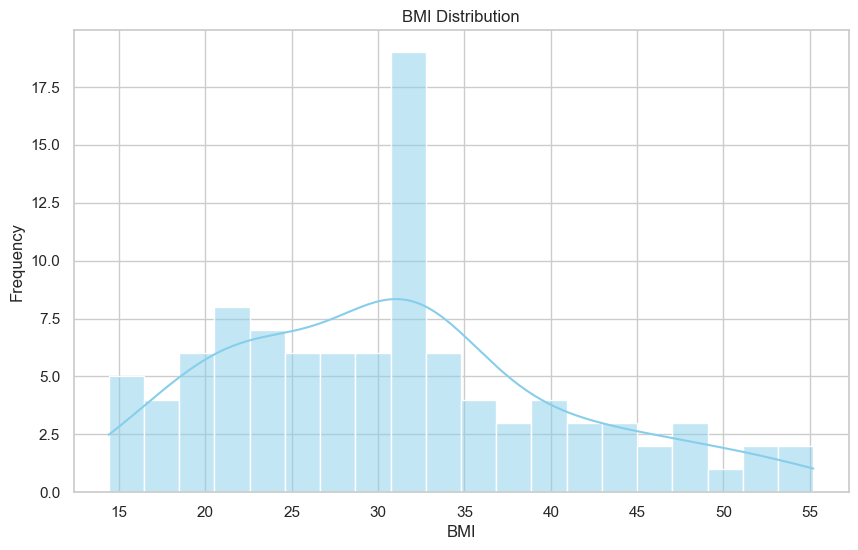

In [12]:
# Plot 1: Histogram of BMI distribution
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.histplot(df['calculated_bmi'], bins=20, kde=True, color='skyblue')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
bmi_plot_path = os.path.join(output_dir, "bmi_distribution.png")
plt.savefig(bmi_plot_path)
plt.show()

C:\Users\SKYTECH\AppData\Local\Temp\ipykernel_2960\965940580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='risk_category', palette='Set2')


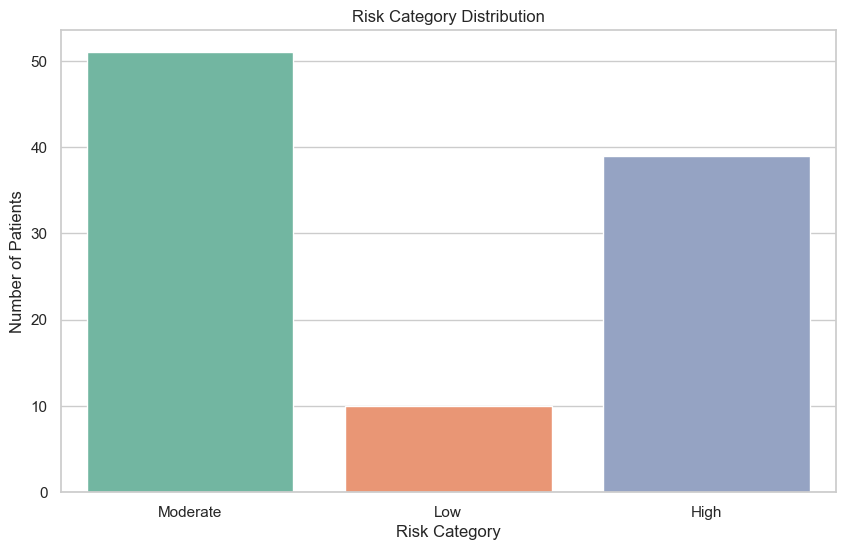

In [13]:
# Plot 2: Bar chart of risk categories
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='risk_category', palette='Set2')
plt.title('Risk Category Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Number of Patients')
risk_plot_path = os.path.join(output_dir, "risk_category_distribution.png")
plt.savefig(risk_plot_path)
plt.show()

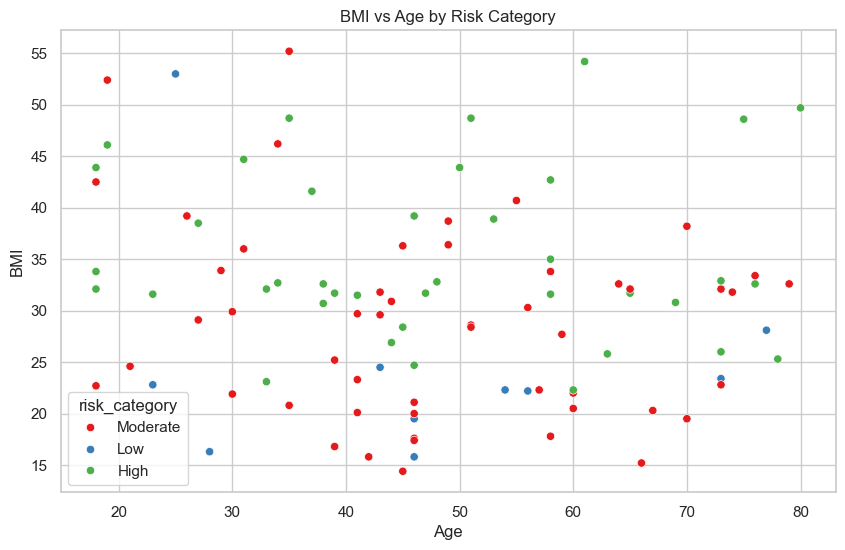

In [14]:
# Plot 3: Scatter plot of BMI vs Age
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='calculated_bmi', hue='risk_category', palette='Set1')
plt.title('BMI vs Age by Risk Category')
plt.xlabel('Age')
plt.ylabel('BMI')
scatter_plot_path = os.path.join(output_dir, "bmi_vs_age_scatter.png")
plt.savefig(scatter_plot_path)
plt.show()

In [15]:
# Save processed data with assessments
output_csv_path = os.path.join(output_dir, "patient_health_assessments.csv")
df.to_csv(output_csv_path, index=False)

print("Processed patient data, calculated health assessments, and saved visualizations and results.")

Processed patient data, calculated health assessments, and saved visualizations and results.


##  Key Outcomes

### Individual Assessments
- **BMI recalculated** for each patient using height and weight.
- **Blood pressure categorized** into Normal, Elevated, Hypertension Stage 1, Stage 2, or Crisis.
- **Risk levels assigned** (Low, Moderate, High) based on BMI, blood pressure, glucose, smoking status, and activity level.

### Population-Level Insights
- **BMI Distribution (Histogram)**  
  Shows how BMI values spread across the population, highlighting clusters of overweight and obese patients.
  
- **Risk Category Distribution (Bar Chart)**  
  Displays the number of patients in each risk category (Low, Moderate, High). This helps identify the proportion of patients needing urgent intervention.
  
- **BMI vs Age (Scatter Plot)**  
  Plots BMI against age, colored by risk category. This reveals age-related trends in obesity and health risk.

---

##  Example Findings from the Dataset
- **High BMI cases:** Several patients exceed BMI 40 (e.g., P027 with BMI 53.0, P035 with BMI 55.2).  
- **Blood pressure extremes:** Patients like P005 (179/76) and P090 (179/113) fall into **Hypertension Stage 2**.  
- **Glucose concerns:** Multiple patients show blood glucose ≥ 10 mmol/L (e.g., P003, P008, P012), indicating possible diabetes risk.  
- **Lifestyle impact:** Sedentary smokers consistently fall into **High risk** categories, while active non-smokers often remain in **Low risk**.

---

##  How to Use These Results
- **Clinicians:** Identify high-risk patients for targeted interventions (weight management, hypertension treatment, smoking cessation).  
- **Researchers:** Use the distribution charts to study correlations between lifestyle factors and health outcomes.  
- **Policy makers:** Assess population health risks and design preventive programs.
